# Finetuneando Stable Difusion

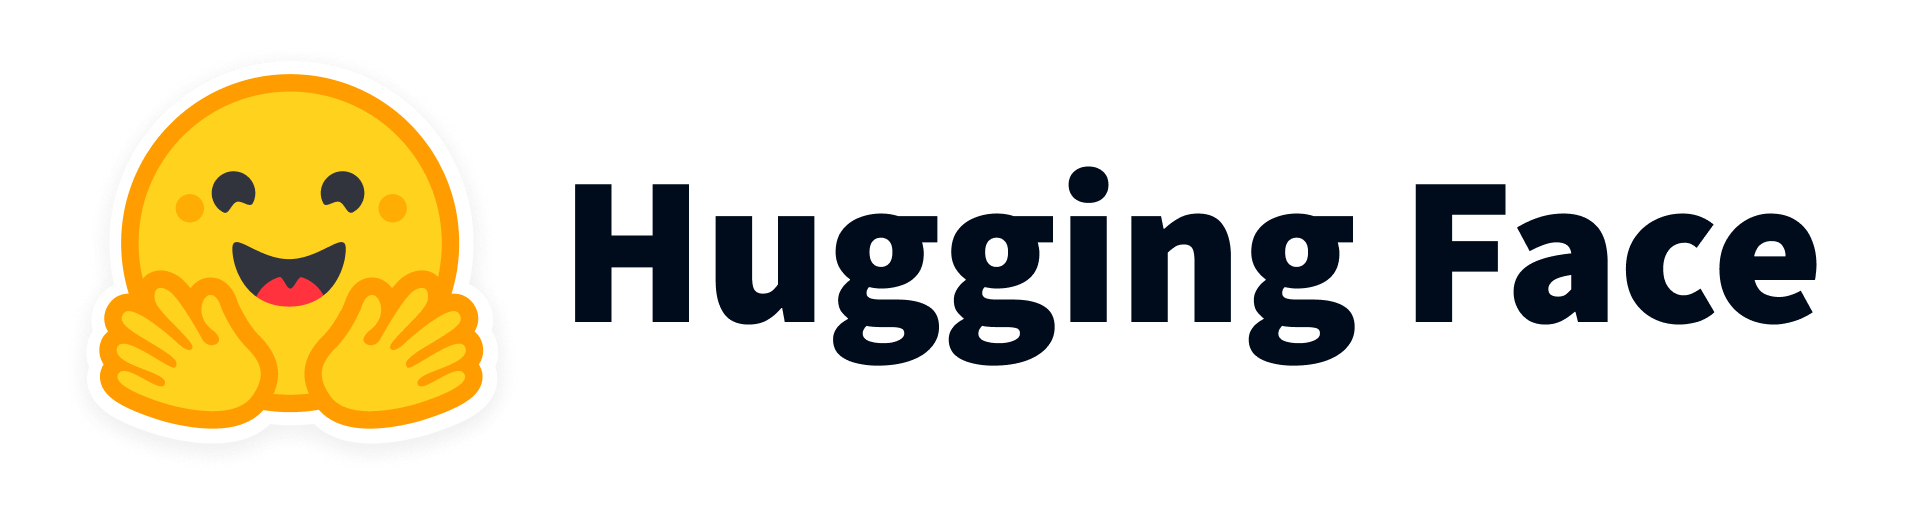

version 1.0

# 0. Instalación de librerías

In [ ]:
!pip install -qq diffusers "datasets>=2.16,<2.17" accelerate

In [1]:
# Importamos las librerias necesarias:
from diffusers import StableDiffusionPipeline, DDPMScheduler
from diffusers import UNet2DConditionModel, AutoencoderKL, LMSDiscreteScheduler
from transformers import CLIPTextModel, CLIPTokenizer
from datasets import load_dataset
from accelerate import Accelerator
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from tqdm import tqdm

In [2]:
# Vamos a utilizar GPU, necesaria para el entrenamiento:

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# 1. Comportamiento original del modelo pre-entrenado

In [3]:
pretrained_model_name = "CompVis/stable-diffusion-v1-4"

# Cargamos un modelo pre-entrenado Stable Diffusion:
pipe = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
).to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

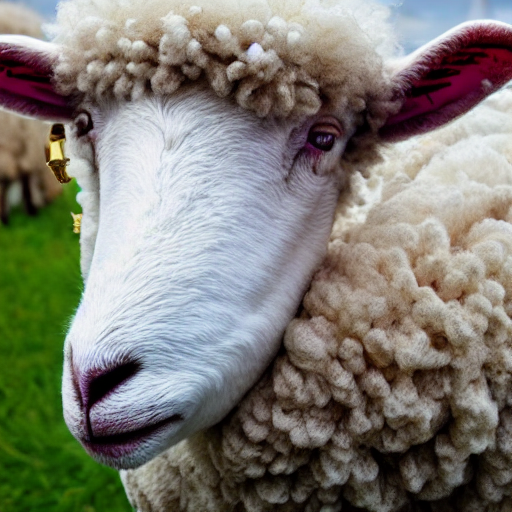

In [4]:
# Vamos a generar una imagen con un prompt:
prompt = "an image of a crazy sheep"
image = pipe(prompt).images[0]

image

# 2. Cargamos el dataset para finetunear

In [5]:
# Cargando el dataset de Pokemon con texto:
dataset_name = "reach-vb/pokemon-blip-captions"
max_train_samples = 10  # tiene que ser menor que 833 (el numero de filas que tiene el dataset original)


dataset = load_dataset(dataset_name, split="train")
if max_train_samples:
    dataset = dataset.select(range(max_train_samples))

# Comprobamos el tamaño de las imagenes del dataset:
size = dataset[0]["image"].size
print(f"Tamaño de las imagenes del dataset: {size}")

Generating train split:   0%|          | 0/833 [00:00<?, ? examples/s]

Tamaño de las imagenes del dataset: (1280, 1280)


In [6]:
# Definimos las transformaciones necesarias para el dataset:
# La resolucion del modelo la podemos encontrar en su model card:
resolution = 512
image_transforms = transforms.Compose([
    transforms.Resize((resolution, resolution)),             # resizing
    transforms.ToTensor(),                                   # convertir a tensor
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # normalizacion
])

Imagen transformada:


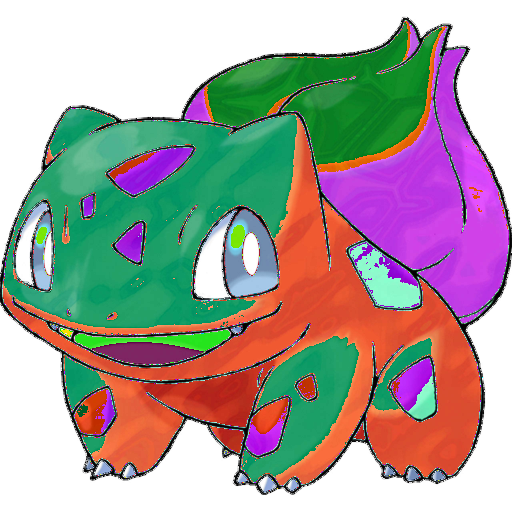

In [7]:
# Aplicamos la transformacion a una imagen aleatoria del dataset:
original_image = dataset[0]["image"]
transformed_image = image_transforms(original_image)
transformed_pil_image = transforms.ToPILImage()(transformed_image)

print("Imagen transformada:")
transformed_pil_image

In [8]:
# Creamos un Dataset wrapper para la hora del entrenamiento:
batch_size = 2  # no puede ser mayor por la limitacion de GPU

class Text2ImageDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]
        image = image_transforms(example["image"].convert("RGB"))
        token = tokenizer(example["text"], padding="max_length", truncation=True, max_length=tokenizer.model_max_length, return_tensors="pt")
        return {
            "pixel_values": image,
            "input_ids": token.input_ids.squeeze(0),
            "attention_mask": token.attention_mask.squeeze(0),
        }

train_dataset = Text2ImageDataset(dataset)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 3. Cargamos las componentes del modelo por separado

In [9]:
# Antes de cargar todas las componentes en GPU, la vaciamos:
del pipe
torch.cuda.empty_cache()

In [10]:
# Tokenizador:
tokenizer = CLIPTokenizer.from_pretrained(pretrained_model_name, subfolder='tokenizer')

# Scheduler:
noise_scheduler = DDPMScheduler.from_pretrained(pretrained_model_name, subfolder="scheduler")

# Text Encoder (CLIP):
text_encoder = CLIPTextModel.from_pretrained(
    pretrained_model_name,
    subfolder="text_encoder",
).to(device)

# VAE: Autoencoder:
vae = AutoencoderKL.from_pretrained(
    pretrained_model_name,
    subfolder="vae",
).to(device)

# La UNet:
unet = UNet2DConditionModel.from_pretrained(
    pretrained_model_name,
    subfolder="unet",
).to(device)

/home/alexd/entornos/env-WithGPU/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [11]:
# Congelamos los pesos del VAE y del Text Encoder, ya que solo queremos finetunear la UNet:
vae.eval()
text_encoder.eval()

for param in vae.parameters():
    param.requires_grad = False
for param in text_encoder.parameters():
    param.requires_grad = False

# 4. Preparamos el entrenamiento:

In [12]:
# Optimizador:
learning_rate = 1e-5
optimizer = torch.optim.AdamW(unet.parameters(), lr=learning_rate)

# Acelerador:
accelerator = Accelerator()
unet, optimizer, train_dataloader = accelerator.prepare(unet, optimizer, train_dataloader)
print(accelerator.device)

cuda


# 5. Proceso de entrenamiento: finetuning

In [13]:
# Training loop:
num_epochs = 1

for epoch in range(num_epochs):
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch}")

    for batch in progress_bar:

        # Se pasan los pixeles al espacio latente con el encoder del VAE:
        with torch.no_grad():
            latents = vae.encode(batch["pixel_values"].to(accelerator.device)).latent_dist.sample()
            latents = latents * 0.18215

        # Proceso de difusion hacia delante:
        # 1. Creamos ruido aleatorio
        noise = torch.randn_like(latents)
        # 2. Cogemos un timestep aleatorio:
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=latents.device).long()
        # 3. Añadimos ruido al vector del espacio latente:
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # Codificamos el texto:
        encoder_hidden_states = text_encoder(batch["input_ids"].to(accelerator.device))[0]

        # Con el vector con ruido, el timestep, y el vector de texto, hacemos la prediccion de ruido:
        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

        # Calculamos el error y actualizamos los parametros:
        loss = torch.nn.functional.mse_loss(noise_pred, noise)
        accelerator.backward(loss)
        optimizer.step()
        optimizer.zero_grad()

        progress_bar.set_postfix(loss=loss.item())

Epoch 0: 100%|██████████| 5/5 [21:22<00:00, 256.50s/it, loss=0.0679]


In [14]:
# Guardamos el modelo finetuneado:
output_dir = "./finetuned-model"

unet.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

('./finetuned-model/tokenizer_config.json', './finetuned-model/tokenizer.json')

# 6. Cargamos el modelo ya finetuneado para generar imágenes:

In [15]:
# Cargamos del repo de Alvaro:
repo_id = 'alvarosooli/finetuned-sd-1.4-pontia-academic'

finetuned_unet = UNet2DConditionModel.from_pretrained(repo_id)
finetuned_unet.to(device)

print('Modelo finetuneado cargado correctamente!')

/home/alexd/entornos/env-WithGPU/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/1.83k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Modelo finetuneado cargado correctamente!


In [16]:
from diffusers import StableDiffusionPipeline

# Cargamos el modelo pre-entrenado pero sustituyendo la UNet por la nuestra:
pipe = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
    unet=finetuned_unet,
).to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

In [ ]:
# Generamos Pokemons con el modelo finetuneado:
prompt = "an image of a crazy sheep"
image = pipe(prompt).images[0]

image

  0%|          | 0/50 [00:00<?, ?it/s]